In [4]:
import csv
import re
import subprocess
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split

WINDOW_SIZE = 5
MIN_SAMPLES_PER_DEVICE = 10
RANDOM_STATE = 42
TEST_SIZE = 0.2

DAY_DIRS = {
    "2018-03-20": Path("2018/03/20"),
    "2018-03-21": Path("2018/03/21"),
}

RESULT_DIR = Path("cross_day_results")
PLOT_DIR = Path("exploratory_plots")
RESULT_DIR.mkdir(exist_ok=True)
PLOT_DIR.mkdir(exist_ok=True)

FEATURE_COLS = [
    "pkt_count",
    "total_bytes",
    "outgoing_pkts",
    "incoming_pkts",
    "outgoing_bytes",
    "incoming_bytes",
    "avg_pkt_size",
    "max_pkt_size",
    "min_pkt_size",
]


## Device Mapping and Tcpdump Parsing


In [5]:
IP_HEADER_RE = re.compile(
    r"^(?P<time>\d+\.\d+) IP .* proto (?P<proto>[A-Z]+) "
    r"\((?P<proto_num>\d+)\), length (?P<length>\d+)"
)
ENDPOINT_RE = re.compile(r"^\s+(?P<src>\S+) > (?P<dst>\S+):")


def load_device_mapping(mapping_path="device_mapping.csv"):
    ip_to_device = {}
    with open(mapping_path, newline="") as f:
        for row in csv.reader(f):
            if len(row) >= 2:
                device = row[0].strip()
                ip_address = row[1].strip()
                ip_to_device[ip_address] = device
    return ip_to_device


def load_device_mapping_table(mapping_path="device_mapping.csv"):
    return pd.read_csv(mapping_path, header=None, names=["device", "ip"]).dropna()


def endpoint_to_ip(endpoint):
    endpoint = endpoint.rstrip(":,")
    parts = endpoint.split(".")
    if len(parts) >= 4 and all(part.isdigit() for part in parts[:4]):
        return ".".join(parts[:4])
    return endpoint


def iter_ip_packets_from_tcpdump(pcap_path):
    cmd = ["tcpdump", "-tt", "-n", "-v", "-r", str(pcap_path), "ip"]
    proc = subprocess.Popen(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.DEVNULL,
        text=True,
    )

    current = None
    for line in proc.stdout:
        header = IP_HEADER_RE.match(line)
        if header:
            current = {
                "time": float(header.group("time")),
                "protocol": int(header.group("proto_num")),
                "length": int(header.group("length")),
            }
            continue

        endpoints = ENDPOINT_RE.match(line)
        if endpoints and current is not None:
            current["src_ip"] = endpoint_to_ip(endpoints.group("src"))
            current["dst_ip"] = endpoint_to_ip(endpoints.group("dst"))
            yield current
            current = None

    proc.wait()
    if proc.returncode != 0:
        raise RuntimeError(f"tcpdump failed while reading {pcap_path}")


In [6]:
device_map_df = load_device_mapping_table()
ip_to_device = load_device_mapping()

device_map_df.head()



                  device           ip
0                Gateway  192.168.0.1
1            GoogleOnHub  192.168.0.2
2  SamsungSmartThingsHub  192.168.0.4
3          PhilipsHUEHub  192.168.0.5
4             InsteonHub  192.168.0.6
Mapped devices: 66
Mapped IP addresses: 66


In [7]:
device_map_df['device'].nunique(), len(ip_to_device)

(66, 66)

## Windowed Feature Extraction

In [8]:
def extract_day_features(day_dir, ip_to_device, cache_path=None, window_size=WINDOW_SIZE):
    if cache_path is not None:
        cache_path = Path(cache_path)
        if cache_path.exists():
            return pd.read_csv(cache_path)

    grouped = defaultdict(
        lambda: {
            "pkt_count": 0,
            "total_bytes": 0,
            "outgoing_pkts": 0,
            "incoming_pkts": 0,
            "outgoing_bytes": 0,
            "incoming_bytes": 0,
            "lengths": [],
        }
    )
    first_time = None
    pcap_paths = sorted(Path(day_dir).glob("eth1-*"))

    for file_idx, pcap_path in enumerate(pcap_paths, start=1):
        if file_idx == 1 or file_idx % 48 == 0 or file_idx == len(pcap_paths):
            print(f"Extracting {day_dir} ({file_idx}/{len(pcap_paths)})")

        for pkt in iter_ip_packets_from_tcpdump(pcap_path):
            src = pkt["src_ip"]
            dst = pkt["dst_ip"]
            if src in ip_to_device:
                device = ip_to_device[src]
                direction = "outgoing"
            elif dst in ip_to_device:
                device = ip_to_device[dst]
                direction = "incoming"
            else:
                continue

            if first_time is None:
                first_time = pkt["time"]

            window_start = ((pkt["time"] - first_time) // window_size) * window_size
            entry = grouped[(window_start, device)]
            entry["pkt_count"] += 1
            entry["total_bytes"] += pkt["length"]
            entry["lengths"].append(pkt["length"])

            if direction == "outgoing":
                entry["outgoing_pkts"] += 1
                entry["outgoing_bytes"] += pkt["length"]
            else:
                entry["incoming_pkts"] += 1
                entry["incoming_bytes"] += pkt["length"]

    if not grouped:
        raise ValueError(f"No mapped device packets found in {day_dir}")

    feature_rows = []
    for (window_start, device), values in grouped.items():
        lengths = values.pop("lengths")
        feature_rows.append(
            {
                "window_start": window_start,
                "device": device,
                **values,
                "avg_pkt_size": sum(lengths) / len(lengths),
                "max_pkt_size": max(lengths),
                "min_pkt_size": min(lengths),
                "label": device,
            }
        )

    feature_df = pd.DataFrame(feature_rows).sort_values(["window_start", "device"])

    if cache_path is not None:
        cache_path.parent.mkdir(parents=True, exist_ok=True)
        feature_df.to_csv(cache_path, index=False)

    return feature_df


In [9]:
feature_tables = {}
for day, day_dir in DAY_DIRS.items():
    cache_path = RESULT_DIR / f"features_{day.replace('-', '_')}.csv"
    feature_tables[day] = extract_day_features(
        day_dir,
        ip_to_device,
        cache_path=cache_path,
        window_size=WINDOW_SIZE,
    )
    print(
        f"{day}: rows={len(feature_tables[day]):,}, "
        f"devices={feature_tables[day]['device'].nunique()}"
    )

day20 = feature_tables["2018-03-20"]
day21 = feature_tables["2018-03-21"]

day20.head()


2018-03-20: rows=257,070, devices=45
2018-03-21: rows=293,303, devices=49


,window_start,device,pkt_count,total_bytes,outgoing_pkts,incoming_pkts,outgoing_bytes,incoming_bytes,avg_pkt_size,max_pkt_size,min_pkt_size,label
0,0.0,AmazonEchoGen1,6,606,4,2,485,121,101.000000,187,40,AmazonEchoGen1
1,0.0,Gateway,2,168,2,0,168,0,84.000000,84,84,Gateway
2,0.0,GoogleHomeMini,22,1728,13,9,912,816,78.545455,156,52,GoogleHomeMini
3,0.0,HarmonKardonInvoke,9,2308,5,4,1584,724,256.444444,1289,52,HarmonKardonInvoke
4,0.0,LogitechLogiCircle,232,183500,145,87,178976,4524,790.948276,1500,52,LogitechLogiCircle


## Plots

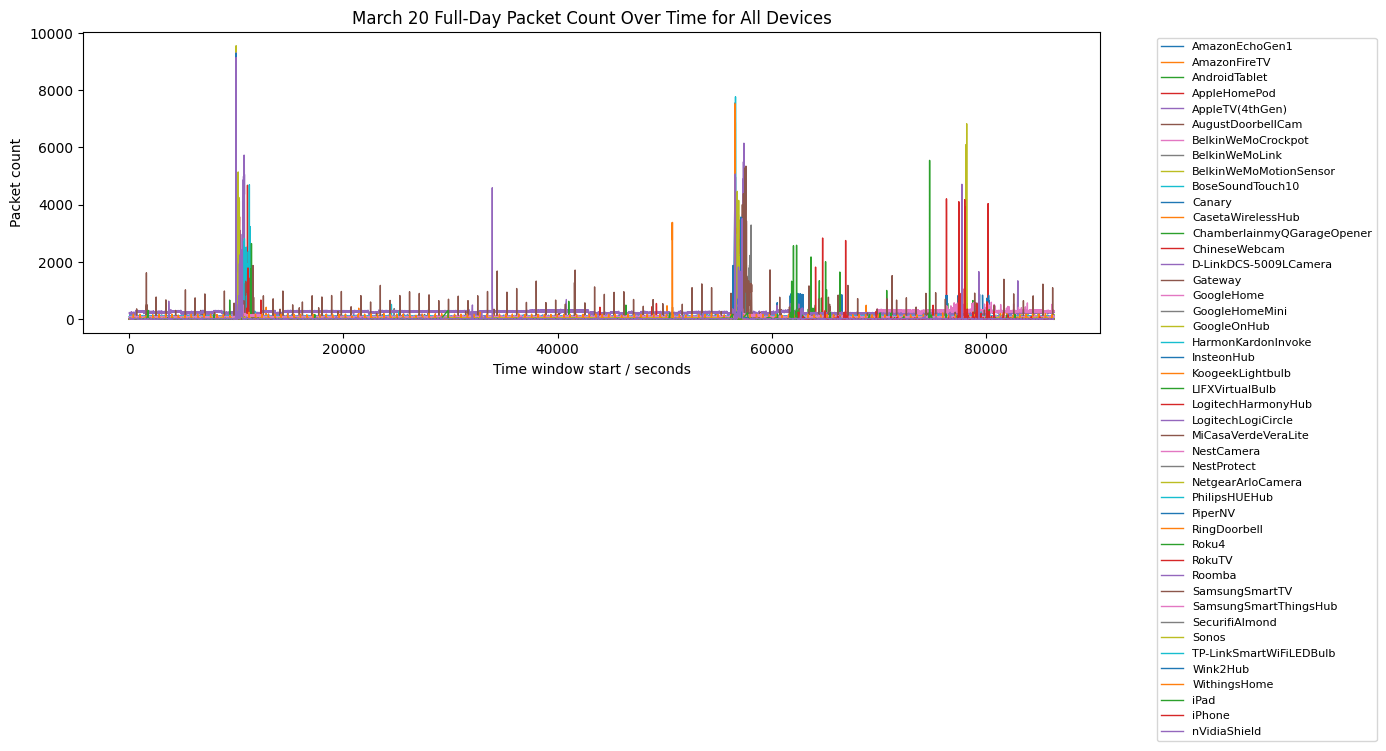

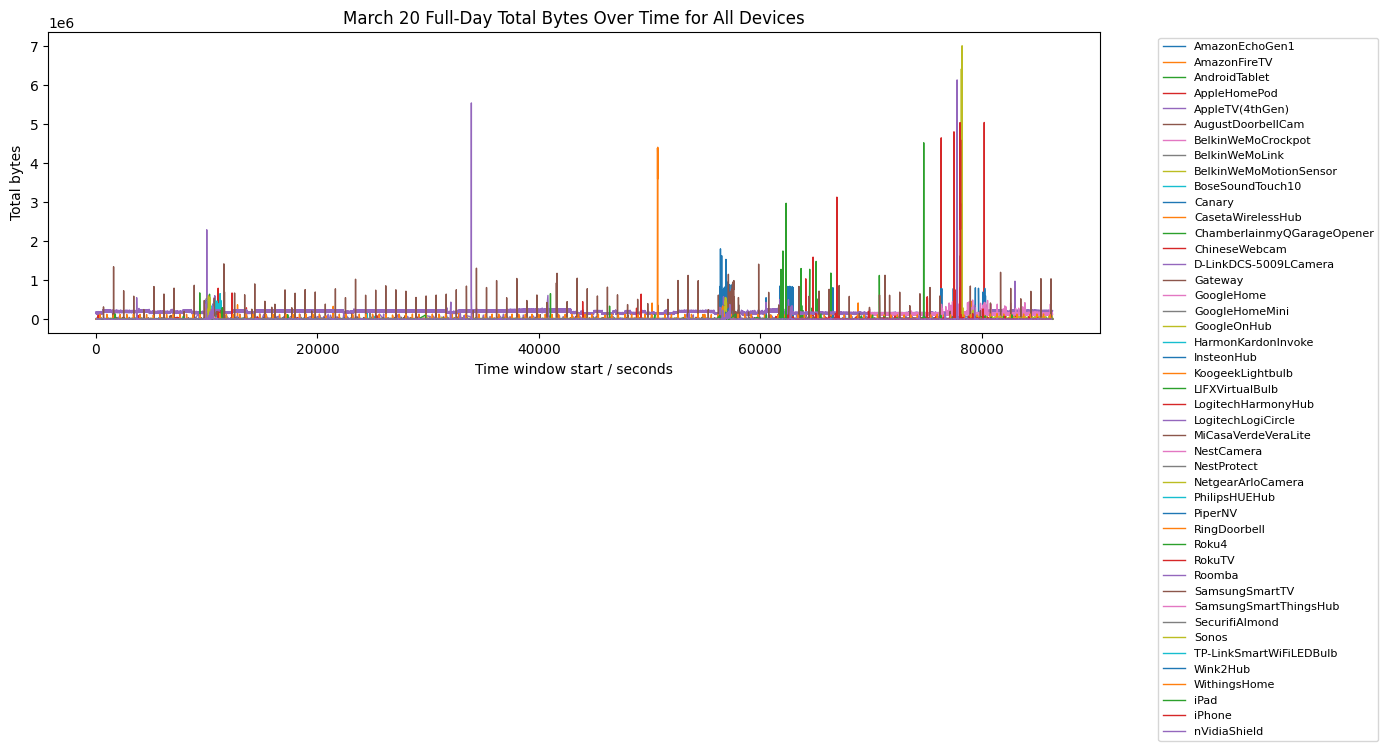

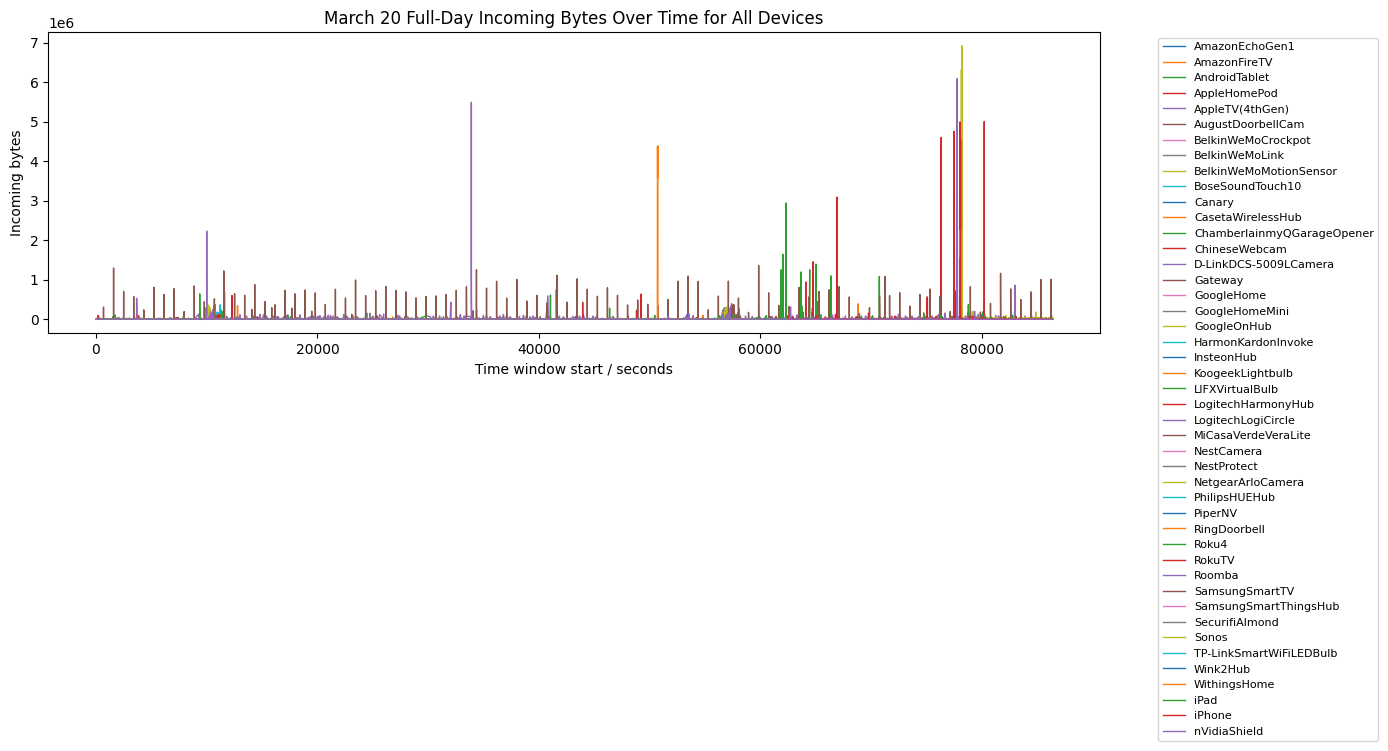

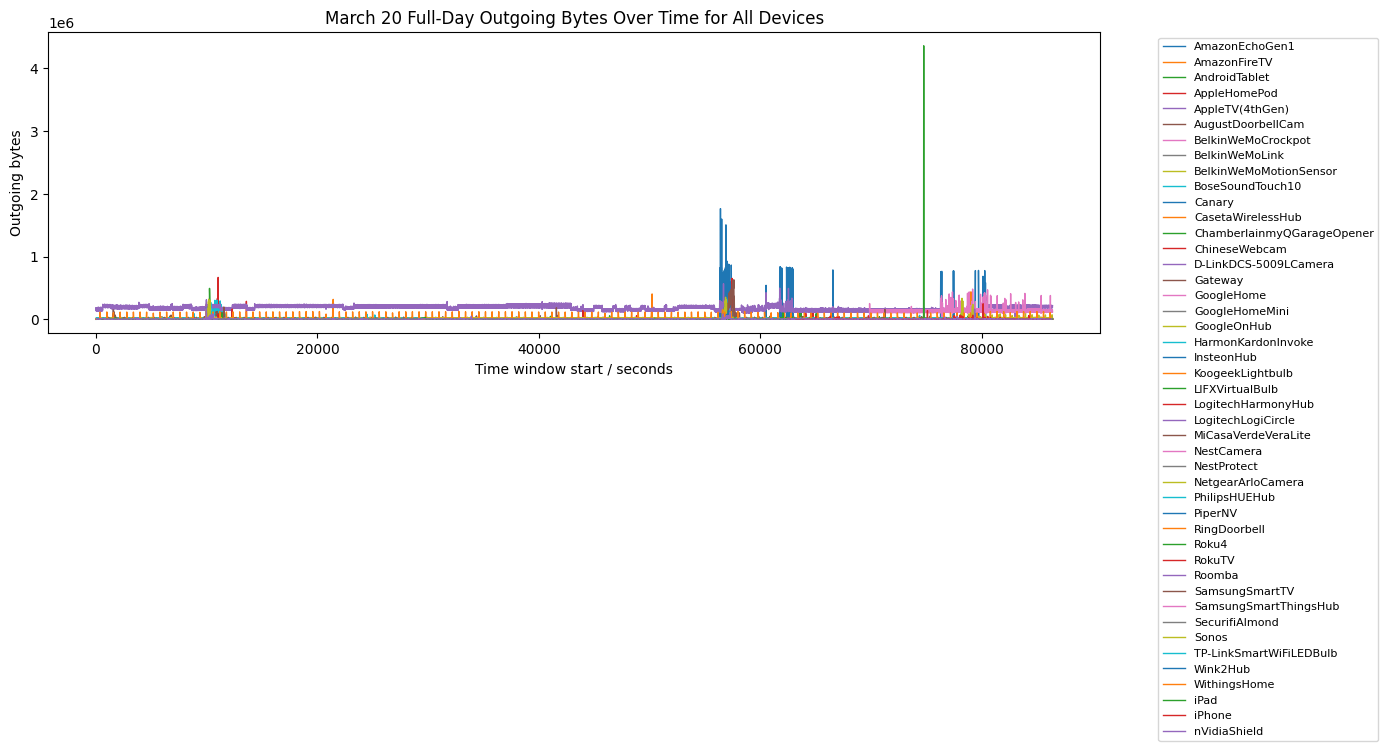

In [13]:
def plot_device_timeseries(df, value_col, title, ylabel):
    plt.figure(figsize=(14, 6))
    for device, device_df in df.groupby("device"):
        plt.plot(device_df["window_start"], device_df[value_col], label=device, linewidth=1)

    plt.xlabel("Time window start / seconds")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()


plot_device_timeseries(
    day20,
    "pkt_count",
    "March 20 Full-Day Packet Count Over Time for All Devices",
    "Packet count"
)
plot_device_timeseries(
    day20,
    "total_bytes",
    "March 20 Full-Day Total Bytes Over Time for All Devices",
    "Total bytes"
)
plot_device_timeseries(
    day20,
    "incoming_bytes",
    "March 20 Full-Day Incoming Bytes Over Time for All Devices",
    "Incoming bytes"
)
plot_device_timeseries(
    day20,
    "outgoing_bytes",
    "March 20 Full-Day Outgoing Bytes Over Time for All Devices",
    "Outgoing bytes"
)


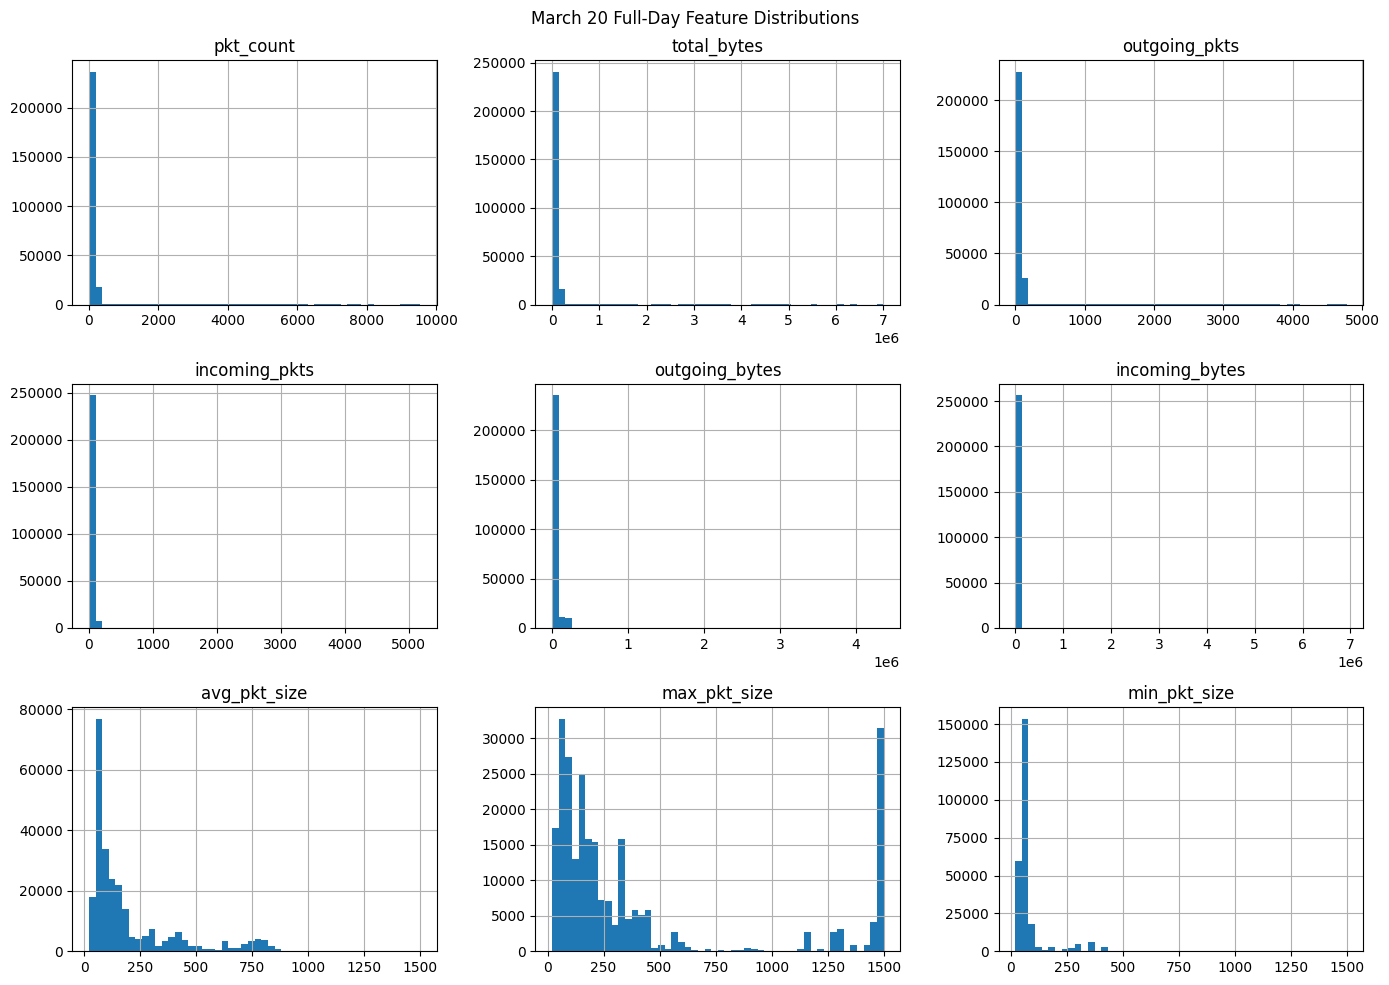

In [14]:
day20[FEATURE_COLS].hist(figsize=(14, 10), bins=50)
plt.suptitle("March 20 Full-Day Feature Distributions")
plt.tight_layout()
plt.show()


## Device Classification

In [15]:
def filter_labels_for_same_day(feature_df, min_samples=MIN_SAMPLES_PER_DEVICE):
    counts = feature_df["label"].value_counts()
    labels = counts[counts >= min_samples].index
    return feature_df[feature_df["label"].isin(labels)].copy()


def filter_common_labels(train_df, test_df, min_samples=MIN_SAMPLES_PER_DEVICE):
    train_counts = train_df["label"].value_counts()
    test_counts = test_df["label"].value_counts()
    labels = sorted(
        set(train_counts[train_counts >= min_samples].index)
        & set(test_counts[test_counts >= min_samples].index)
    )
    return (
        train_df[train_df["label"].isin(labels)].copy(),
        test_df[test_df["label"].isin(labels)].copy(),
        labels,
    )


def train_classifier(train_df, feature_cols=FEATURE_COLS):
    clf = RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1,
    )
    clf.fit(train_df[feature_cols], train_df["label"])
    return clf


def evaluate_model(name, clf, test_df, feature_cols=FEATURE_COLS):
    y_true = test_df["label"]
    y_pred = clf.predict(test_df[feature_cols])
    return {
        "experiment": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "n_test": len(test_df),
        "n_devices": y_true.nunique(),
        "report": classification_report(y_true, y_pred, zero_division=0),
        "confusion_matrix": pd.DataFrame(
            confusion_matrix(y_true, y_pred, labels=clf.classes_),
            index=clf.classes_,
            columns=clf.classes_,
        ),
    }


def same_day_experiment(name, feature_df):
    filtered = filter_labels_for_same_day(feature_df)
    train_df, test_df = train_test_split(
        filtered,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=filtered["label"],
    )
    clf = train_classifier(train_df)
    result = evaluate_model(name, clf, test_df)
    result["n_train"] = len(train_df)
    return result


def cross_day_experiment(name, train_df, test_df):
    train_filtered, test_filtered, labels = filter_common_labels(train_df, test_df)
    clf = train_classifier(train_filtered)
    result = evaluate_model(name, clf, test_filtered)
    result["n_train"] = len(train_filtered)
    result["common_labels"] = labels
    return result


def result_filename(experiment_name):
    return (
        experiment_name.lower()
        .replace(" ", "_")
        .replace("-", "")
        .replace(">", "to")
    )


### Same-Day Device Classification


In [23]:
results = [
    same_day_experiment("2018-03-20", day20),
    same_day_experiment("2018-03-21", day21),
    cross_day_experiment("2018-03-20 -> 2018-03-21", day20, day21),
    cross_day_experiment("2018-03-21 -> 2018-03-20", day21, day20),
]

comparison = pd.DataFrame(
    [
        {
            "experiment": result["experiment"],
            "accuracy": result["accuracy"],
            "n_train": result["n_train"],
            "n_test": result["n_test"],
            "n_devices": result["n_devices"],
        }
        for result in results
    ]
)
# comparison.to_csv(RESULT_DIR / "accuracy_comparison.csv", index=False)

# for result in results:
#     filename = result_filename(result["experiment"])
#     result["confusion_matrix"].to_csv(RESULT_DIR / f"{filename}_confusion_matrix.csv")
#     with open(RESULT_DIR / f"{filename}_classification_report.txt", "w") as f:
#         f.write(result["report"])

comparison


,experiment,accuracy,n_train,n_test,n_devices
0,2018-03-20,0.854242,205652,51414,44
1,2018-03-21,0.868923,234638,58660,48
2,2018-03-20 -> 2018-03-21,0.837237,257066,290398,44
3,2018-03-21 -> 2018-03-20,0.799814,290398,257066,44


In [21]:
len(results)

4

In [25]:
print(results[0]["experiment"])
print(results[0]["accuracy"])
print(results[0]["report"])


2018-03-20
0.854242035243319
                            precision    recall  f1-score   support

            AmazonEchoGen1       0.97      0.84      0.90      1638
              AmazonFireTV       0.89      0.93      0.91      1306
             AndroidTablet       0.44      0.33      0.37        86
              AppleHomePod       0.40      0.25      0.31        16
           AppleTV(4thGen)       0.48      0.75      0.59       275
         AugustDoorbellCam       0.89      0.93      0.91      1394
        BelkinWeMoCrockpot       0.82      0.93      0.87       648
            BelkinWeMoLink       0.59      0.51      0.55       495
    BelkinWeMoMotionSensor       0.53      0.68      0.59       577
          BoseSoundTouch10       0.99      0.79      0.88       198
                    Canary       0.96      0.87      0.91      1958
         CasetaWirelessHub       0.84      0.71      0.77       712
ChamberlainmyQGarageOpener       0.97      0.19      0.32      1726
             Chine

In [26]:
print(results[1]["experiment"])
print(results[1]["accuracy"])
print(results[1]["report"])


2018-03-21
0.8689226048414592
                            precision    recall  f1-score   support

            AmazonEchoGen1       1.00      0.86      0.92      1583
              AmazonFireTV       0.89      0.94      0.92      1244
             AndroidTablet       0.62      0.57      0.59        72
              AppleHomePod       0.57      0.44      0.50        59
           AppleTV(4thGen)       0.74      0.66      0.70       121
         AugustDoorbellCam       0.90      0.97      0.93      1337
              BelkinNetcam       0.96      0.64      0.77       430
        BelkinWeMoCrockpot       0.85      0.80      0.82       584
            BelkinWeMoLink       0.44      0.42      0.43       402
    BelkinWeMoMotionSensor       0.48      0.65      0.55       515
          BelkinWeMoSwitch       0.39      0.68      0.50        98
          BoseSoundTouch10       0.99      0.81      0.89      2263
                    Canary       0.95      0.96      0.96      1969
         CasetaWi

In [27]:
print(results[2]["experiment"])
print(results[2]["accuracy"])
print(results[2]["report"])


2018-03-20 -> 2018-03-21
0.837237171054897
                            precision    recall  f1-score   support

            AmazonEchoGen1       0.96      0.85      0.90      7917
              AmazonFireTV       0.89      0.94      0.91      6220
             AndroidTablet       0.36      0.39      0.37       358
              AppleHomePod       0.11      0.01      0.02       296
           AppleTV(4thGen)       0.27      0.63      0.37       605
         AugustDoorbellCam       0.89      0.94      0.92      6683
        BelkinWeMoCrockpot       0.83      0.80      0.81      2920
            BelkinWeMoLink       0.49      0.45      0.47      2012
    BelkinWeMoMotionSensor       0.51      0.73      0.60      2575
          BoseSoundTouch10       1.00      0.61      0.76     11312
                    Canary       0.93      0.90      0.91      9847
         CasetaWirelessHub       0.85      0.61      0.71      2494
ChamberlainmyQGarageOpener       0.95      0.10      0.17      8606
    

In [28]:
print(results[3]["experiment"])
print(results[3]["accuracy"])
print(results[3]["report"])


2018-03-21 -> 2018-03-20
0.7998140555343763
                            precision    recall  f1-score   support

            AmazonEchoGen1       0.98      0.81      0.88      8191
              AmazonFireTV       0.78      0.90      0.84      6528
             AndroidTablet       0.33      0.15      0.20       431
              AppleHomePod       0.00      0.05      0.01        81
           AppleTV(4thGen)       0.69      0.40      0.50      1378
         AugustDoorbellCam       0.67      0.92      0.78      6968
        BelkinWeMoCrockpot       0.69      0.90      0.78      3239
            BelkinWeMoLink       0.53      0.49      0.51      2477
    BelkinWeMoMotionSensor       0.45      0.64      0.53      2883
          BoseSoundTouch10       0.29      0.80      0.42       989
                    Canary       0.94      0.94      0.94      9790
         CasetaWirelessHub       0.96      0.39      0.56      3561
ChamberlainmyQGarageOpener       0.85      0.10      0.18      8630
   